In [18]:
import pandas as pd
import numpy as np

from pandas.plotting import register_matplotlib_converters

from utilities import get_number_practices, get_percentage_practices, deciles_chart, OUTPUT_DIR

from IPython.display import HTML, display, Markdown
import matplotlib.pyplot as plt
register_matplotlib_converters()

%matplotlib inline
%config InlineBackend.figure_format='png'
plt.rcParams["axes.grid"] = True

In [3]:
measures_df = pd.read_csv('../output/measures.csv.gz', parse_dates=["interval_start", "interval_end"])
print(measures_df.head())

           measure interval_start interval_end     ratio  numerator  \
0  asthma_practice     2024-01-01   2024-01-31  0.019481          3   
1  asthma_practice     2024-01-01   2024-01-31  0.000000          0   
2  asthma_practice     2024-01-01   2024-01-31  0.027586          4   
3  asthma_practice     2024-01-01   2024-01-31  0.024845          4   
4  asthma_practice     2024-01-01   2024-01-31  0.000000          0   

   denominator  practice  asthma_code  copd_code  qrisk_code  tsh_code  \
0          154      16.0          NaN        NaN         NaN       NaN   
1          151      44.0          NaN        NaN         NaN       NaN   
2          145      60.0          NaN        NaN         NaN       NaN   
3          161      71.0          NaN        NaN         NaN       NaN   
4          158      32.0          NaN        NaN         NaN       NaN   

   alt_code  cholesterol_code  hba1c_code  rbc_code  sodium_code  \
0       NaN               NaN         NaN       NaN         

In [4]:
%%capture --no-display

sentinel_measures = ["qrisk2", "asthma", "copd", "sodium", "cholesterol", "alt", "tsh", "rbc", 'hba1c', 'systolic_bp', 'medication_review']

sentinel_measure_codelist_mapping_dict = {"systolic_bp":"opensafely-systolic-blood-pressure-qof", "qrisk":"opensafely-cvd-risk-assessment-score-qof", "cholesterol": "opensafely-cholesterol-tests", "alt": "opensafely-alanine-aminotransferase-alt-tests", "tsh": "opensafely-thyroid-stimulating-hormone-tsh-testing", "rbc": "opensafely-red-blood-cell-rbc-tests", "hba1c": "opensafely-glycated-haemoglobin-hba1c-tests", "sodium": "opensafely-sodium-tests-numerical-value", "asthma": "opensafely-asthma-annual-review-qof", "copd": "opensafely-chronic-obstructive-pulmonary-disease-copd-review-qof"}

codelist_dict = {}
for measure in sentinel_measures:

    if measure =="qrisk2":
        measure= "qrisk"
    
    if measure == 'medication_review':
        codelist_1 = pd.read_csv('../codelists/opensafely-care-planning-medication-review-simple-reference-set-nhs-digital.csv')
        codelist_1['term'] = codelist_1['term'].str.rstrip('(procedure)').str.rstrip()
        codelist_2 = pd.read_csv('../codelists/nhsd-primary-care-domain-refsets-medrvw_cod.csv')
        codelist_dict[measure] = codelist_1.merge(codelist_2, on=['code', 'term'], how='outer')
    else:
        codelist_name = sentinel_measure_codelist_mapping_dict[measure]
        codelist = pd.read_csv(f'../codelists/{codelist_name}.csv')
        codelist_dict[measure] = codelist

In [5]:
def drop_irrelevant_practices(df):
    """Drops irrelevant practices from the given measure table.

    An irrelevant practice has zero events during the study period.

    Args:
        df: A measure table.

    Returns:
        A copy of the given measure table with irrelevant practices dropped.
    """

    is_relevant = df.groupby("practice").ratio.any()
    return df[df.practice.isin(is_relevant[is_relevant == True].index)]

def create_child_table(df, code_df, code_column, term_column, measure, nrows=5):
    """
    Args:
        df: A measure table.
        code_df: A codelist table.
        code_column: The name of the code column in the codelist table.
        term_column: The name of the term column in the codelist table.
        measure: The measure ID.
        nrows: The number of rows to display.

    Returns:
        A table of the top `nrows` codes.
    """
    event_counts = (
        df.groupby(f"{measure}_code")["numerator"]
        .sum()  # We can't use .count() because the measure column contains zeros.
        .rename_axis(code_column)
        .rename("Events")
        .reset_index()
        .sort_values("Events", ascending=False)
    )

    # round events to nearest 5
    event_counts["Events"] = np.round(event_counts["Events"] / 5) * 5

    # calculate % makeup of each code
    total_events = event_counts["Events"].sum()
    event_counts["Proportion of codes (%)"] = round(
        (event_counts["Events"] / total_events) * 100, 2
    )

    # Gets the human-friendly description of the code for the given row
    # e.g. "Systolic blood pressure".
    code_df = code_df.set_index(code_column).rename(
        columns={term_column: "Description"}
    )
    event_counts = event_counts.set_index(code_column).join(code_df).reset_index()

    # Cast the code to an integer.
    event_counts[code_column] = event_counts[code_column].astype(int)

    # check that codes not in the top 5 rows have >5 events
    outside_top_5_percent = 1 - ((event_counts.head(5)["Events"].sum()) / total_events)

    if 0 < (outside_top_5_percent * total_events) <= 5:
        # drop percent column
        event_counts = event_counts.loc[:, ["code", "Description"]]

    else:
        # give more logical column ordering
        event_counts_with_count = event_counts.loc[
            :, ["code", "Description", "Events", "Proportion of codes (%)"]
        ]

        event_counts = event_counts.loc[
            :, ["code", "Description", "Proportion of codes (%)"]
        ]

    if len(event_counts["code"]) > 1:
        event_counts.loc[
            event_counts["Proportion of codes (%)"] == 0, "Proportion of codes (%)"
        ] = "< 0.005"
        event_counts.loc[
            event_counts["Proportion of codes (%)"] == 100, "Proportion of codes (%)"
        ] = "> 99.995"

        event_counts_with_count.loc[
            event_counts_with_count["Proportion of codes (%)"] == 0,
            "Proportion of codes (%)",
        ] = "< 0.005"
        event_counts_with_count.loc[
            event_counts_with_count["Proportion of codes (%)"] == 100,
            "Proportion of codes (%)",
        ] = "> 99.995"

    # return top n rows
    return event_counts.head(5), event_counts_with_count.head()


def get_number_events_mil(measure_table):
    """Gets the number of events per million, rounded to 2DP.

    Args:
        measure_table: A measure table.
        measure_id: The measure ID.
    """
    num_events = measure_table["numerator"].sum()
    return num_events, np.round(num_events / 1_000_000, 2)


In [6]:

measure_dfs = {}
child_tables = {}

for measure in sentinel_measures:
    if measure =="qrisk2":
        measure = "qrisk"
    
    measure_subset_practice = measures_df.loc[measures_df['measure'] == f"{measure}_practice", ["measure", "interval_start", "interval_end", "ratio", "numerator", "denominator", "practice"]]
    measure_subset_code = measures_df.loc[measures_df['measure'] == f"{measure}_code", ["measure", "interval_start", "interval_end", "ratio", "numerator", "denominator", f"{measure}_code"]]
    

    measure_subset_practice = drop_irrelevant_practices(measure_subset_practice)

    measure_dfs[measure] = {"practice": measure_subset_practice, "code": measure_subset_code}



    event_counts, event_count_with_count = create_child_table(measure_subset_code, codelist_dict[measure], 'code', 'term', measure)
    child_tables[measure] = event_counts, event_count_with_count

/tmp/ipykernel_1299/56451058.py:75: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '< 0.005' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  event_counts.loc[
/tmp/ipykernel_1299/56451058.py:82: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '< 0.005' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  event_counts_with_count.loc[
/tmp/ipykernel_1299/56451058.py:75: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '< 0.005' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  event_counts.loc[
/tmp/ipykernel_1299/56451058.py:82: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '< 0.005' has dtype 

In [8]:
print(f'measure_subset_practice: {measure_subset_practice}')
print(f'measure_subset_code: {measure_subset_code}')
print(f'measure_dfs: {measure_dfs}')
print(f'child_tables: {child_tables}')

measure_subset_practice:                           measure interval_start interval_end     ratio  \
1106   medication_review_practice     2024-01-01   2024-01-31  0.116883   
1107   medication_review_practice     2024-01-01   2024-01-31  0.079470   
1108   medication_review_practice     2024-01-01   2024-01-31  0.124138   
1109   medication_review_practice     2024-01-01   2024-01-31  0.149068   
1110   medication_review_practice     2024-01-01   2024-01-31  0.075949   
...                           ...            ...          ...       ...   
14061  medication_review_practice     2024-11-01   2024-11-30  0.229630   
14062  medication_review_practice     2024-11-01   2024-11-30  0.234848   
14063  medication_review_practice     2024-11-01   2024-11-30  0.228571   
14064  medication_review_practice     2024-11-01   2024-11-30  0.212903   
14065  medication_review_practice     2024-11-01   2024-11-30  0.194030   

       numerator  denominator  practice  
1106          18          154   

In [19]:
def generate_sentinel_measure(
        measure_df,
        measure,
        code_column,
        codelist_links,
    ):
    """Generates tables and charts for the measure with the given ID.

    Args:
        data_dict: A mapping of measure IDs to measure tables.
        data_dict_practice: A mapping of measure IDs to "practice only" measure tables.
        codelist_dict: A mapping of measure IDs to codelist tables.
        measure: A measure ID.
        code_column: The name of the code column in the codelist table.
        term_column: The name of the term column in the codelist table.
        dates_list: Not used.
        interactive: Flag indicating whether or not the chart should be interactive.
    """

    practices_included = get_number_practices(measure_df)
    num_events, num_events_mil = get_number_events_mil(measure_df)
    measure_df["rate_per_1000"] = measure_df["ratio"] * 1000
    df = deciles_chart(
        measure_df,
        "interval_start",
        "rate_per_1000",
        interactive=False,
        height=600,
        width=1000,
        output_path=f"{OUTPUT_DIR}/deciles_chart_{measure}.png",
    )

    childs_df, childs_df_with_count = child_tables[measure]

  
    display(
        Markdown(f"Practices included: {practices_included}"),
    )

    childs_df = childs_df.rename(columns={code_column: code_column.title()})
    childs_df.to_csv(f"{OUTPUT_DIR}/code_table_{measure}.csv")

    childs_df_with_count = childs_df_with_count.rename(
        columns={code_column: code_column.title()}
    )
    childs_df_with_count.to_csv(f"{OUTPUT_DIR}/code_table_{measure}_with_count.csv")

    if len(codelist_links)>1:
        display(
            Markdown(f"#### Most Common Codes <a href={codelist_links[0]}>(Codelist 1)</a>, <a href={codelist_links[1]}>(Codelist 2)</a>"),
            HTML(childs_df.to_html(index=False)),
        )

    else:
        display(
            Markdown(f"#### Most Common Codes <a href={codelist_links[0]}>(Codelist)</a>"),
            HTML(childs_df.to_html(index=False)),
        )

    display(
        Markdown(f"Total events: {num_events_mil:.2f}M"),
    )

    return print(df)

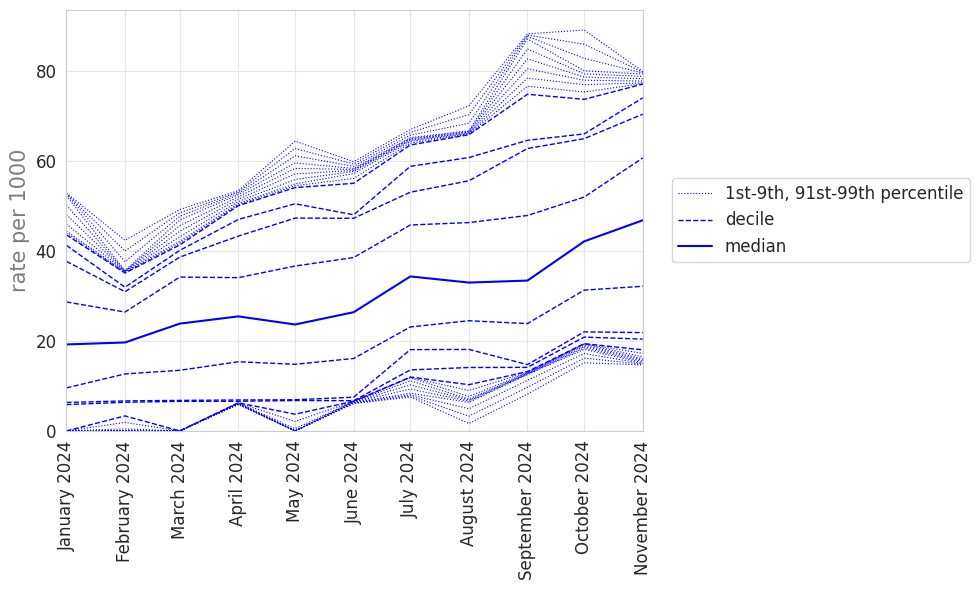

Practices included: 100

#### Most Common Codes <a href=https://www.opencodelists.org/codelist/opensafely/alanine-aminotransferase-alt-tests/2298df3e/>(Codelist)</a>

Code,Description,Proportion of codes (%)
389586005,Plasma alanine aminotransferase level,8.44
1013211000000103,Plasma alanine aminotransferase level,7.94
390961000,Plasma alanine aminotransferase level,7.94
390318006,Plasma alanine aminotransferase level,7.85
34608000,Alanine aminotransferase measurement,7.85


Total events: 0.01M

None


In [20]:
generate_sentinel_measure(
    measure_dfs['alt']['practice'],
    'alt',
    'code',
    codelist_links=["https://www.opencodelists.org/codelist/opensafely/alanine-aminotransferase-alt-tests/2298df3e/"]
)

In [34]:
# Extract underlying data for decile chart
from utilities import compute_deciles
measures_df["rate_per_1000"] = measures_df["ratio"] * 1000
decile_data = compute_deciles(measure_dfs['alt']['practice'], "interval_start", "rate_per_1000", True)
decile_data.to_csv('../output/deciles_table_counts_per_week_per_practice.csv')

In [33]:
print(measure_dfs['alt']['practice'])

            measure interval_start interval_end     ratio  numerator  \
432    alt_practice     2024-01-01   2024-01-31  0.012987          2   
433    alt_practice     2024-01-01   2024-01-31  0.026490          4   
434    alt_practice     2024-01-01   2024-01-31  0.000000          0   
435    alt_practice     2024-01-01   2024-01-31  0.006211          1   
436    alt_practice     2024-01-01   2024-01-31  0.031646          5   
...             ...            ...          ...       ...        ...   
13387  alt_practice     2024-11-01   2024-11-30  0.051852          7   
13388  alt_practice     2024-11-01   2024-11-30  0.015152          2   
13389  alt_practice     2024-11-01   2024-11-30  0.050000          7   
13390  alt_practice     2024-11-01   2024-11-30  0.058065          9   
13391  alt_practice     2024-11-01   2024-11-30  0.052239          7   

       denominator  practice  rate_per_1000  
432            154      16.0      12.987013  
433            151      44.0      26.490066